In [15]:
from google.colab import drive
drive.mount('/content/drive')

%run '/content/drive/MyDrive/Repos/MachineLearning-ML001/helper/helper.ipynb'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Modeling Class Probabilities via Logistic Regression**

Despite its name, **logistic regression** is a widely used linear model for classification, not regression. It serves as a more robust alternative to the perceptron, particularly because the perceptron fails to converge if the classes are not perfectly linearly separable.

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch03/figures/03_03.png" width="600">
</p>

## **1.1. Logistic regression and conditional probabilities**

To understand logistic regression as a probabilistic model, we first define the **odds** in favor of a positive event (the event we want to predict):
$$\text{Odds} = \frac{p}{1-p}$$
*(Where $p$ is the conditional probability that an example belongs to class 1 given its features, $p := p(y=1|\mathbf{x})$).*

The **logit function** is the natural logarithm of these odds (log-odds). It takes input values in the range $[0, 1]$ and transforms them to the entire real-number range:
$$\text{logit}(p) = \log\left(\frac{p}{1 - p}\right)$$

In logistic regression, we assume a linear relationship between the log-odds and the weighted inputs (net input, $z$):
$$\text{logit}(p) = \mathbf{w}^T\mathbf{x} + b$$

To predict the actual probability $p$ given the features, we need the inverse of the logit function. This inverse is called the **logistic sigmoid function** (or simply the sigmoid function):
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
*(Where $z$ is the net input: $z = \mathbf{w}^T\mathbf{x} + b$)*

**Key properties of the sigmoid function:**
* Maps any real-numbered net input to a probability range of $[0, 1]$.
* Creates a characteristic S-shaped curve.
* Approaches $1$ as $z \to \infty$ and approaches $0$ as $z \to -\infty$.
* The intercept is at $\sigma(0) = 0.5$.

**Plot the Sigmoid Function**

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2238/1037530521.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma (z)$')


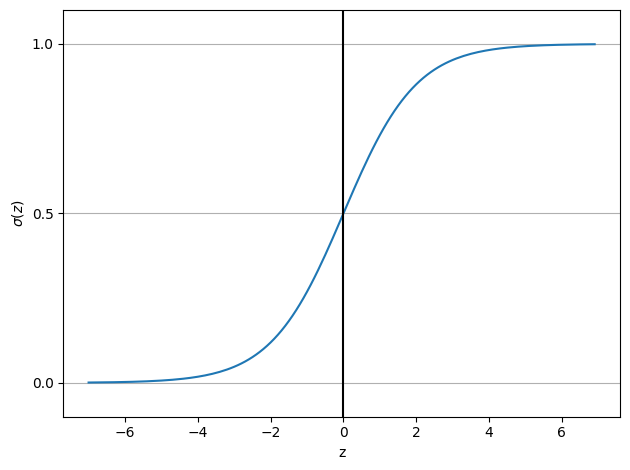

In [16]:
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
sigma_z = sigmoid(z)

plt.plot(z, sigma_z)
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel('$\sigma (z)$')

plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

## **1.2. Learning Model Weights via the Logistic Loss Function**

To fit the parameters (weights $w$ and bias $b$) of a logistic regression model, we need an objective function to optimize. Unlike the Mean Squared Error (MSE) used in models like Adaline, logistic regression uses a loss function derived from maximum likelihood estimation.

### 1.2.1. The Likelihood Function
Assuming that the individual examples in our dataset are independent, we want to maximize the **likelihood** ($\mathcal{L}$) of the training labels given the features.

For a binary classification problem (classes $0$ and $1$), we treat the label as a Bernoulli variable. The probability mass function for a single example is:
$$p(y^{(i)} | \mathbf{x}^{(i)}) = \left(\sigma(z^{(i)})\right)^{y^{(i)}} \left(1 - \sigma(z^{(i)})\right)^{1 - y^{(i)}}$$

Using the multiplication rule for independent events, the likelihood for the entire dataset is the product of these individual probabilities:
$$\mathcal{L}(\mathbf{w}, b | \mathbf{x}) = \prod_{i=1}^n \left(\sigma(z^{(i)})\right)^{y^{(i)}} \left(1 - \sigma(z^{(i)})\right)^{1 - y^{(i)}}$$

### 1.2.2. The Log-Likelihood Function
In practice, it is mathematically easier to maximize the natural logarithm of the likelihood function, known as the **log-likelihood**.
* **Prevents numerical underflow:** Very small likelihoods can cause issues in computation.
* **Simplifies derivation:** Converts products into sums, making it easier to calculate derivatives.

$$l(\mathbf{w}, b | \mathbf{x}) = \sum_{i=1}^n \left[ y^{(i)} \log(\sigma(z^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right]$$

### 1.2.3. The Logistic Loss Function
While we could use gradient ascent to *maximize* the log-likelihood, it is standard practice to rewrite this as a loss function ($L$) to *minimize* using gradient descent. We do this by simply multiplying the log-likelihood by $-1$:

$$L(\mathbf{w}, b) = \sum_{i=1}^n \left[ -y^{(i)} \log(\sigma(z^{(i)})) - (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right]$$

### 1.2.4. Loss for a Single Training Example
To better understand this function, let's look at the loss calculated for just one training example:
$$L(\sigma(z), y; \mathbf{w}, b) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z))$$

This equation simplifies cleanly depending on the true class label ($y$):
* **If $y = 1$:** The second term becomes zero, leaving $L = -\log(\sigma(z))$
* **If $y = 0$:** The first term becomes zero, leaving $L = -\log(1 - \sigma(z))$

**Interpretation:** The loss approaches $0$ if the model correctly predicts the class probability. However, if the prediction is completely wrong, the loss goes toward infinity. This ensures wrong predictions are heavily penalized.

**Plot the loss function used in logistic regression**

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2238/844776843.py:19: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma(z)$')


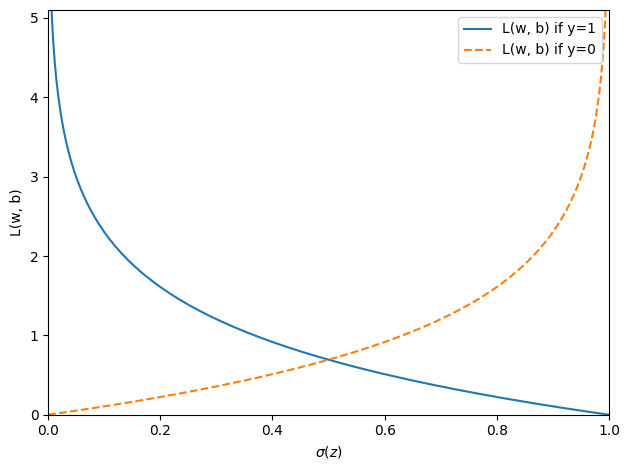

In [17]:
def loss_1(z):
    return - np.log(sigmoid(z))


def loss_0(z):
    return - np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)

c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label='L(w, b) if y=1')

c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle='--', label='L(w, b) if y=0')

plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel('$\sigma(z)$')
plt.ylabel('L(w, b)')
plt.legend(loc='best')
plt.tight_layout()
#plt.savefig('figures/03_04.png', dpi=300)
plt.show()

# **2. Manual Implementation of Logistic Regression**

In [18]:
class LogisticRegressionGD:
    """Gradient descent-based logistic regression classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after training.
    b_ : Scalar
      Bias unit after fitting.
    losses_ : list
       Log loss function values in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : Instance of LogisticRegressionGD

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * errors.mean()
            loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / X.shape[0]
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [19]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

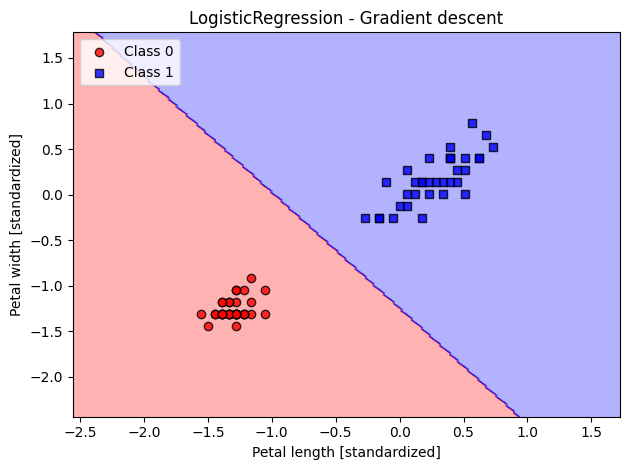

In [20]:
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

lrgd = LogisticRegressionGD(eta=0.3, n_iter=1000, random_state=1)
lrgd.fit(X_train_01_subset,
         y_train_01_subset)

plot_decision_regions(X=X_train_01_subset,
                      y=y_train_01_subset,
                      classifier=lrgd)

plt.title('LogisticRegression - Gradient descent')
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# **3. Training Logistic Regression with Scikit-Learn**

Scikit-learn handles multiclass classification "off the shelf."

### Key Concepts

* **Optimized Implementation:** Scikit-learn provides a highly efficient version of logistic regression compared to manual implementations like Adaline.
* **Multiclass Support:** It automatically handles more than two classes using two primary strategies:
    * **OvR (One-vs-Rest):** The model trains a separate classifier for each class.
    * **Multinomial:** Also known as *Softmax Regression*. This is the **default** and recommended setting for mutually exclusive classes.
* **Mutually Exclusive Classes:** This refers to datasets (like Iris) where each sample belongs to exactly **one** category, as opposed to "multilabel" classification where a sample could belong to several.

In [21]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0, solver='lbfgs', multi_class='ovr')
lr.fit(X_train_std, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100.0, multi_class='ovr')

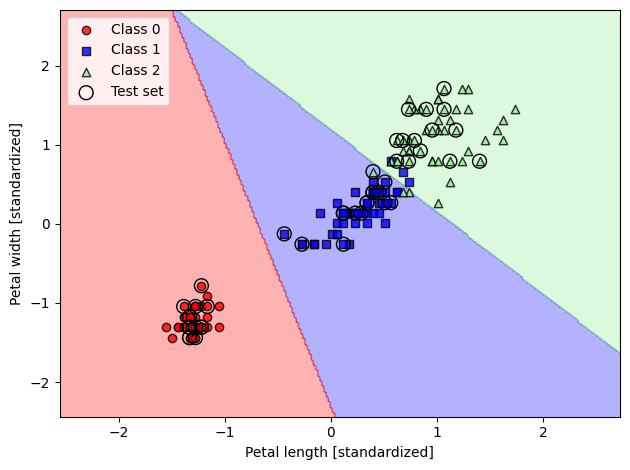

In [23]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X_combined_std, y_combined, classifier=lr, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
lr.predict_proba(X_test_std[:3, :])

array([[6.63770505e-09, 1.44747233e-01, 8.55252760e-01],
       [8.34031210e-01, 1.65968790e-01, 3.20815954e-13],
       [8.48822884e-01, 1.51177116e-01, 2.57998350e-14]])

In [25]:
lr.predict_proba(X_test_std[:3, :]).sum(axis=1)

array([1., 1., 1.])

In [26]:
lr.predict_proba(X_test_std[:3, :]).argmax(axis=1)

array([2, 0, 0])

In [27]:
lr.predict(X_test_std[:3, :])

array([2, 0, 0])

In [28]:
lr.predict(X_test_std[0, :].reshape(1, - 1))

array([2])